<a href="https://colab.research.google.com/github/krupalithakur/CellposeVsCellSAM/blob/main/Cellpose_Fine_Tuning_on_Unseen_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

# Base dataset directory
base_dir = '/content/drive/MyDrive/S-BIAD634'

# Define subfolders
rawimages_dir = os.path.join(base_dir, 'rawimages')
train_base_dir = os.path.join(base_dir, 'train_sets')  # Will hold subsets (n5, n10, etc.)
test_dir = os.path.join(base_dir, 'test_set')          # Fixed test set for eval
models_dir = os.path.join(base_dir, 'trained_models')  # To store fine-tuned models

# Create folders if they don’t exist
for folder in [train_base_dir, test_dir, models_dir]:
    os.makedirs(folder, exist_ok=True)

print("✅ Directory structure initialized.")

✅ Directory structure initialized.


In [ ]:
!pip install cellpose[all]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 123.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 93.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 108.0 MB/s eta 0:00:00
   

In [ ]:
from cellpose import models, io



Welcome to CellposeSAM, cellpose v
cellpose version: 	4.0.6 
platform:       	linux 
python version: 	3.11.13 
torch version:  	2.6.0+cu124! The neural network component of
CPSAM is much larger than in previous versions and CPU excution is slow. 
We encourage users to use GPU/MPS if available. 




In [ ]:
model = models.CellposeModel(gpu=True, pretrained_model='nuclei')

100%|██████████| 1.15G/1.15G [00:08<00:00, 152MB/s]


In [ ]:
import os
from cellpose import models, io
import numpy as np
from PIL import Image

# === Folder setup ===
base_dir = '/content/drive/MyDrive/S-BIAD634/dataset'
rawimages_dir = os.path.join(base_dir, 'rawimages')
train_base_dir = os.path.join(base_dir, 'train_sets')
subset_name = 'n5'
subset_dir = os.path.join(train_base_dir, subset_name)

os.makedirs(subset_dir, exist_ok=True)

# === Load pretrained Cellpose model ===
model = models.CellposeModel(gpu=True, pretrained_model='nuclei')

# === Load first 5 raw images ===
image_files = sorted([f for f in os.listdir(rawimages_dir) if f.endswith('.png')])[:5]

for fname in image_files:
    img_path = os.path.join(rawimages_dir, fname)
    img = io.imread(img_path)

    # Predict segmentation mask
    masks, flows, styles, diams = model.eval([img], diameter=None, channels=[[0, 0]])

    # Save image
    img_save_path = os.path.join(subset_dir, fname)
    Image.fromarray(img).save(img_save_path)

    # Save predicted mask as .npy
    mask_save_path = os.path.join(subset_dir, fname.replace('.png', '_masks.npy'))
    np.save(mask_save_path, masks[0])

print(f"✅ Saved 5 training images and masks in: {subset_dir}")

✅ Saved 5 training images and masks in: /content/drive/MyDrive/S-BIAD634/dataset/train_sets/n5


In [ ]:
import os

subset_dir = '/content/drive/MyDrive/S-BIAD634/dataset/train_sets'
files = os.listdir(subset_dir)
print("Files in n5 folder:", files)

Files in n5 folder: ['n5']


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os

# Path to your n5 folder
subset_dir = '/content/drive/MyDrive/S-BIAD634/dataset/train_sets/n5'

# Load PNG files
image_files = sorted([f for f in os.listdir(subset_dir) if f.lower().endswith('.png')])

# Setup plot
plt.figure(figsize=(12, 10))
count = 0

for fname in image_files:
    mask_path = os.path.join(subset_dir, fname.replace('.png', '_masks.npy'))
    img_path = os.path.join(subset_dir, fname)

    if os.path.exists(mask_path):
        img = np.array(Image.open(img_path))
        mask = np.load(mask_path)

        plt.subplot(3, 2, count + 1)
        plt.imshow(img, cmap='gray')
        plt.imshow(mask, cmap='jet', alpha=0.4)
        plt.title(fname)
        plt.axis('off')
        count += 1

plt.tight_layout()
plt.show()

<Figure size 1200x1000 with 0 Axes>

In [ ]:
import os
from cellpose import models, io
import numpy as np
from PIL import Image

def generate_pseudo_labels(
    base_dir,
    subset_name='n5',
    n_images=5,
    pretrained_model='nuclei',
    mask_suffix='_masks.npy',
    overwrite=False
):
    # Setup paths
    rawimages_dir = os.path.join(base_dir, 'rawimages')
    subset_dir = os.path.join(base_dir, 'train_sets', subset_name)
    os.makedirs(subset_dir, exist_ok=True)

    # Load pretrained model
    model = models.CellposeModel(gpu=True, pretrained_model=pretrained_model)

    # Load raw images
    image_files = sorted([f for f in os.listdir(rawimages_dir) if f.endswith('.png')])[:n_images]

    for idx, fname in enumerate(image_files):
        img_path = os.path.join(rawimages_dir, fname)
        mask_path = os.path.join(subset_dir, fname.replace('.png', mask_suffix))

        if os.path.exists(mask_path) and not overwrite:
            print(f"⏩ Skipping {fname} (mask already exists)")
            continue

        # Load and segment
        img = io.imread(img_path)
        masks, flows, styles, diams = model.eval([img], diameter=None, channels=[[0, 0]])

        # Save image
        img_save_path = os.path.join(subset_dir, fname)
        Image.fromarray(img).save(img_save_path)

        # Save mask
        np.save(mask_path, masks[0])
        print(f"✅ Processed: {fname}")

    print(f"\n✅ Completed pseudo-labeling for {n_images} images → {subset_dir}")

# === RUN ===
generate_pseudo_labels(
    base_dir='/content/drive/MyDrive/S-BIAD634/dataset',
    subset_name='n5',
    n_images=5,
    pretrained_model='nuclei',
    overwrite=False
)


✅ Completed pseudo-labeling for 5 images → /content/drive/MyDrive/S-BIAD634/dataset/train_sets/n5


In [ ]:
from cellpose import models, io, plot
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

# === Load fine-tuned model ===
ft_model_path = '/content/drive/MyDrive/S-BIAD634/dataset/trained_models/n5_model'
model = models.CellposeModel(gpu=True, pretrained_model=ft_model_path)

# === Load test images ===
test_dir = '/content/drive/MyDrive/S-BIAD634/test_set'
test_images = sorted([f for f in os.listdir(test_dir) if f.endswith('.png')])

# === Predict & Visualise
plt.figure(figsize=(12, 10))
for idx, fname in enumerate(test_images[:5]):  # Only first 5 for display
    img_path = os.path.join(test_dir, fname)
    img = io.imread(img_path)

    masks, flows, styles, diams = model.eval([img], diameter=None, channels=[[0, 0]])

    plt.subplot(3, 2, idx + 1)
    plt.imshow(img, cmap='gray')
    plt.imshow(masks[0], cmap='jet', alpha=0.4)
    plt.title(f'Predicted: {fname}')
    plt.axis('off')

plt.tight_layout()
plt.show()

<Figure size 1200x1000 with 0 Axes>

In [1]:
!pip install -q "cellpose[all]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 7.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 114.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 90.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 42.7 MB/s eta 0:00:00
   ━

In [2]:
import os, sys, IPython
IPython.display.clear_output()
print("✅ Now restart the runtime (Runtime > Restart runtime) and re-run from the next cell.")

✅ Now restart the runtime (Runtime > Restart runtime) and re-run from the next cell.


Raw images  ──► (Pretrained Cellpose) ──► Pseudo-masks
      │                                 │
      └────────────── train on ─────────┘  (N images)
                                │
                         Fine‑tuned model_nN
                                │
                Evaluate on same held‑out test set
                                │
                    Record metrics, repeat with bigger N


**Why “increasing number of images”?**

You want to see how performance improves as you add more data. This answers:

How data‑hungry is the model?

Do we get diminishing returns after some N?

What is the smallest N that gives me “good enough” performance?

In [8]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage import io as skio
from skimage.measure import label
from sklearn.model_selection import train_test_split

from cellpose import models, io, plot

In [9]:
# === Adjust these paths if needed ===
BASE_DIR   = '/content/drive/MyDrive/S-BIAD634/dataset'
RAW_DIR    = os.path.join(BASE_DIR, 'rawimages')
GT_DIR     = os.path.join(BASE_DIR, 'groundtruth')              # we’ll read GT from here
TRAINSETS_DIR  = os.path.join(BASE_DIR, 'train_sets')           # where Cellpose-formatted data will go
MODELS_DIR     = os.path.join(BASE_DIR, 'trained_models')       # where fine-tuned models will be saved

# We'll create these two:
CP_TRAIN_DIR   = os.path.join(TRAINSETS_DIR, 'full_gt_train')   # cellpose-ready train set
CP_TEST_DIR    = os.path.join(TRAINSETS_DIR, 'full_gt_test')    # cellpose-ready test set

for p in [TRAINSETS_DIR, MODELS_DIR, CP_TRAIN_DIR, CP_TEST_DIR]:
    os.makedirs(p, exist_ok=True)

In [10]:
raw_pngs  = sorted(glob.glob(os.path.join(RAW_DIR, '*.tif')))
gt_pngs   = sorted(glob.glob(os.path.join(GT_DIR,  '*.tif')))
gt_tifs   = sorted(glob.glob(os.path.join(GT_DIR,  '*.tif')))

print(f"# raw images (.tif): {len(raw_pngs)}")
print(f"# groundtruth TIFs  : {len(gt_pngs)}")
print(f"# groundtruth TIFFs : {len(gt_tifs)}")

# raw images (.tif): 79
# groundtruth TIFs  : 79
# groundtruth TIFFs : 79


In [11]:
def load_gt_mask(base_name, gt_dir):
    """
    Load the ground truth mask for a given image base name.
    Prefer .tif, else .png.
    Returns None if not found.
    """
    tif_path = os.path.join(gt_dir, base_name + '.tif')
    png_path = os.path.join(gt_dir, base_name + '.png')

    if os.path.exists(tif_path):
        return skio.imread(tif_path)
    elif os.path.exists(png_path):
        return skio.imread(png_path)
    else:
        return None

def ensure_instance_labels(mask):
    """
    Ensure mask is labeled 0..N (instance segmentation).
    If binary, convert to labeled instances using connected components.
    """
    mask = np.asarray(mask)
    if np.unique(mask).size <= 2:
        mask = label(mask > 0)
    return mask.astype(np.uint16)

In [12]:
# 4.1 collect all base names (without extension)
raw_bases = [os.path.splitext(os.path.basename(p))[0] for p in raw_pngs]

# 4.2 keep only those that have a matching GT file
valid_bases = []
for base in raw_bases:
    if load_gt_mask(base, GT_DIR) is not None:
        valid_bases.append(base)

print(f"✅ {len(valid_bases)} image/mask pairs found.")

# 4.3 train/test split
train_bases, test_bases = train_test_split(valid_bases, test_size=0.2, random_state=42, shuffle=True)
print(f"Train: {len(train_bases)}, Test: {len(test_bases)}")

ERROR:tifffile:<tifffile.TiffFile 'otherspecimen_3.tif'> shaped series shape does not match page shape


✅ 79 image/mask pairs found.
Train: 63, Test: 16


In [14]:
import os
import glob
from pathlib import Path
import numpy as np
from skimage import io as skio
from skimage.measure import label
from PIL import Image
import tifffile as tiff  # safer tiff reading

# ---------- paths ----------
BASE_DIR   = '/content/drive/MyDrive/S-BIAD634'
RAW_DIR    = os.path.join(BASE_DIR, 'rawimages')
GT_DIR     = os.path.join(BASE_DIR, 'groundtruth')
TRAINSETS_DIR  = os.path.join(BASE_DIR, 'train_sets')
CP_TRAIN_DIR   = os.path.join(TRAINSETS_DIR, 'full_gt_train')
CP_TEST_DIR    = os.path.join(TRAINSETS_DIR, 'full_gt_test')
MODELS_DIR     = os.path.join(BASE_DIR, 'trained_models')

for p in [TRAINSETS_DIR, CP_TRAIN_DIR, CP_TEST_DIR, MODELS_DIR]:
    os.makedirs(p, exist_ok=True)


# ---------- helpers ----------
def index_by_basename(folder, exts=('png','tif','tiff','jpg','jpeg')):
    """
    Return dict: {basename_without_ext : absolute_path_to_file}
    for all files in `folder` that have extension in `exts`.
    """
    idx = {}
    for ext in exts:
        for p in Path(folder).glob(f'*.{ext}'):
            idx[p.stem] = str(p)
    return idx

def read_image_safe(path):
    """Read raw image robustly."""
    suffix = Path(path).suffix.lower()
    if suffix in ('.tif', '.tiff'):
        arr = tiff.imread(path)
    else:
        arr = skio.imread(path)
    # squeeze multi-dim extras if present
    if arr.ndim > 2:
        arr = np.squeeze(arr)
        if arr.ndim > 2:
            arr = arr[0]  # still >2D? take first plane
    return arr

def ensure_instance_labels(mask):
    """Make sure mask is instance-labeled 0..N (not just 0/1)."""
    mask = np.asarray(mask)
    if np.unique(mask).size <= 2:
        mask = label(mask > 0)
    return mask.astype(np.uint16)

In [16]:
import os, re, glob
from pathlib import Path

RAW_DIR = '/content/drive/MyDrive/S-BIAD634/dataset/rawimages'
GT_DIR  = '/content/drive/MyDrive/S-BIAD634/dataset/groundtruth'

def index_by_basename(folder, exts=('tif','tiff','png','jpg','jpeg'), recursive=False):
    pattern = '**/*' if recursive else '*'
    idx = {}
    for ext in exts:
        for p in Path(folder).glob(f'{pattern}.{ext}'):
            idx[p.stem] = str(p)
    return idx

raw_idx = index_by_basename(RAW_DIR, exts=('tif','tiff','png','jpg','jpeg'))
gt_idx  = index_by_basename(GT_DIR,  exts=('tif','tiff','png'), recursive=True)

print(f"#raw files indexed: {len(raw_idx)}")
print(f"#gt  files indexed: {len(gt_idx)}")

# show a few keys to eyeball
print("\nSample RAW basenames:", list(raw_idx.keys())[:10])
print("Sample GT  basenames:", list(gt_idx .keys())[:10])

# what overlaps?
common = set(raw_idx).intersection(set(gt_idx))
print("\n#common after naive match:", len(common))

#raw files indexed: 79
#gt  files indexed: 79

Sample RAW basenames: ['normal_27', 'normal_23', 'normal_1', 'normal_13', 'Neuroblastoma_9', 'normal_19', 'Neuroblastoma_4', 'Ganglioneuroblastoma_10', 'Ganglioneuroblastoma_2', 'Neuroblastoma_0']
Sample GT  basenames: ['Ganglioneuroblastoma_4', 'Ganglioneuroblastoma_1', 'Neuroblastoma_14', 'Neuroblastoma_12', 'Neuroblastoma_10', 'Ganglioneuroblastoma_9', 'Ganglioneuroblastoma_3', 'Neuroblastoma_17', 'Ganglioneuroblastoma_7', 'Ganglioneuroblastoma_10']

#common after naive match: 79


In [17]:
from sklearn.model_selection import train_test_split

# You already have these from the previous step:
# raw_idx = {basename: path_to_raw}
# gt_idx  = {basename: path_to_gt}

common_bases = sorted(set(raw_idx) & set(gt_idx))
print("Total pairs:", len(common_bases))

train_bases, test_bases = train_test_split(common_bases, test_size=0.2, random_state=42, shuffle=True)
print(f"Train: {len(train_bases)}, Test: {len(test_bases)}")

Total pairs: 79
Train: 63, Test: 16


In [18]:
import os
import numpy as np
from pathlib import Path
import tifffile as tiff
from skimage import io as skio
from skimage.measure import label
from PIL import Image

BASE_DIR      = '/content/drive/MyDrive/S-BIAD634/dataset'
TRAINSETS_DIR = os.path.join(BASE_DIR, 'train_sets')
CP_TRAIN_DIR  = os.path.join(TRAINSETS_DIR, 'full_gt_train')
CP_TEST_DIR   = os.path.join(TRAINSETS_DIR, 'full_gt_test')
MODELS_DIR    = os.path.join(BASE_DIR, 'trained_models')
os.makedirs(CP_TRAIN_DIR, exist_ok=True)
os.makedirs(CP_TEST_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

def read_image_safe(path):
    """Read raw or GT image robustly (handles multi-page tiffs)."""
    if Path(path).suffix.lower() in ('.tif', '.tiff'):
        arr = tiff.imread(path)
    else:
        arr = skio.imread(path)
    if arr.ndim > 2:
        arr = np.squeeze(arr)
        if arr.ndim > 2:   # still >2D? take first plane
            arr = arr[0]
    return arr

def ensure_instance_labels(mask):
    """Convert 0/1 mask to 0..N instance-labeled mask if needed."""
    mask = np.asarray(mask)
    if np.unique(mask).size <= 2:
        mask = label(mask > 0)
    return mask.astype(np.uint16)

def write_cellpose_pairs(raw_idx, gt_idx, bases, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    written = 0
    for base in bases:
        img  = read_image_safe(raw_idx[base])
        mask = read_image_safe(gt_idx[base])
        mask = ensure_instance_labels(mask)

        Image.fromarray(img).save(os.path.join(out_dir, base + '.png'))
        np.save(os.path.join(out_dir, base + '_masks.npy'), mask)
        written += 1
    print(f"✅ Wrote {written} image+mask pairs to: {out_dir}")

write_cellpose_pairs(raw_idx, gt_idx, train_bases, CP_TRAIN_DIR)
write_cellpose_pairs(raw_idx, gt_idx, test_bases,  CP_TEST_DIR)

ERROR:tifffile:<tifffile.TiffFile 'otherspecimen_3.tif'> shaped series shape does not match page shape


✅ Wrote 63 image+mask pairs to: /content/drive/MyDrive/S-BIAD634/dataset/train_sets/full_gt_train
✅ Wrote 16 image+mask pairs to: /content/drive/MyDrive/S-BIAD634/dataset/train_sets/full_gt_test


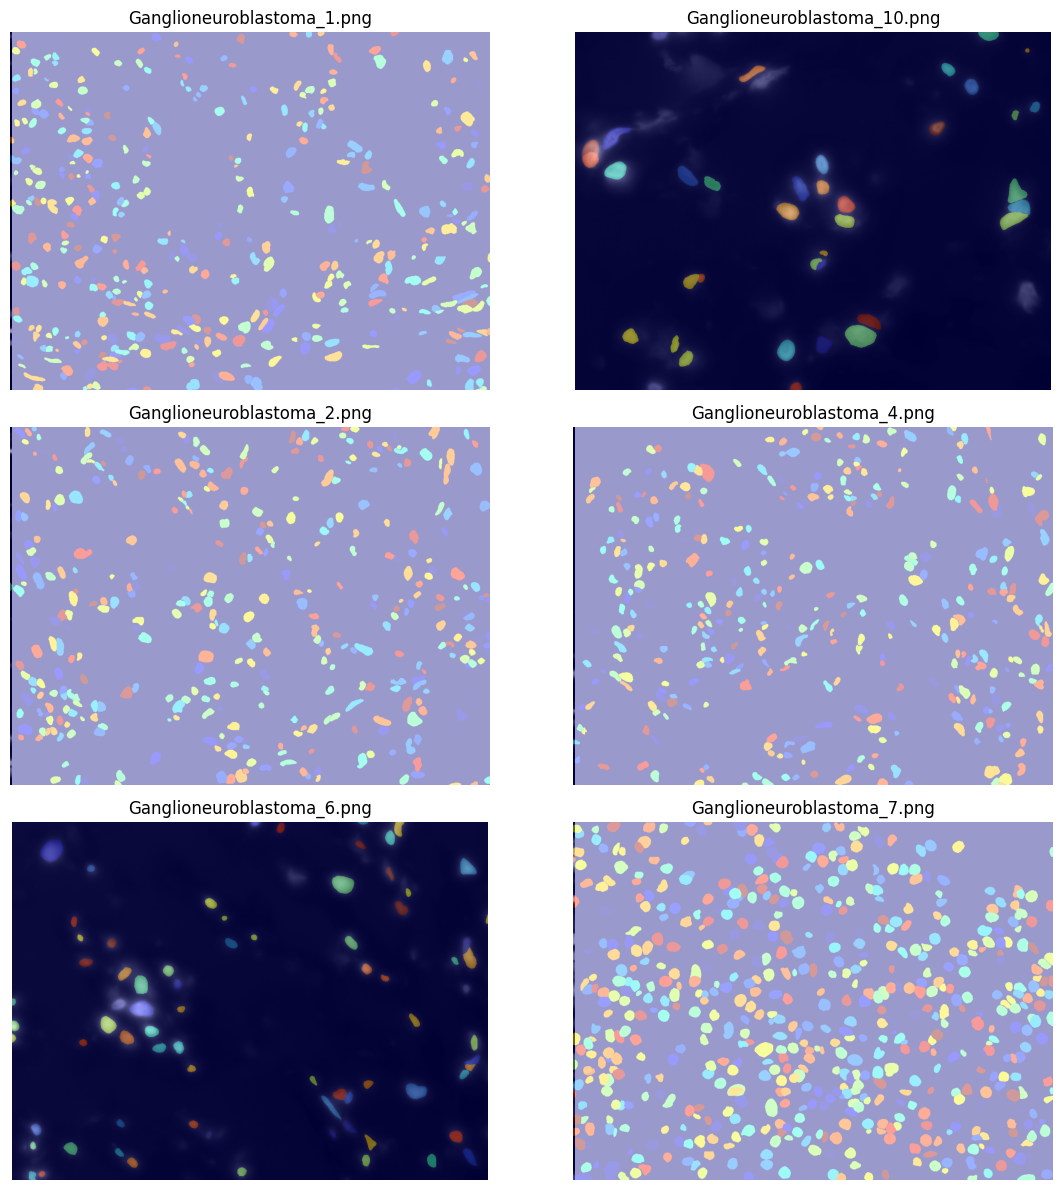

In [19]:
import matplotlib.pyplot as plt

def show_overlays(folder, n=6):
    pngs = sorted([f for f in os.listdir(folder) if f.endswith('.png')])[:n]
    rows = int(np.ceil(len(pngs)/2))
    plt.figure(figsize=(12, 4*rows))
    for i, fname in enumerate(pngs):
        base = os.path.splitext(fname)[0]
        img  = read_image_safe(os.path.join(folder, fname))
        mask = np.load(os.path.join(folder, base + '_masks.npy'))

        plt.subplot(rows, 2, i+1)
        plt.imshow(img, cmap='gray')
        plt.imshow(mask, cmap='jet', alpha=0.4)
        plt.title(fname)
        plt.axis('off')
    plt.tight_layout(); plt.show()

show_overlays(CP_TRAIN_DIR, n=6)

In [20]:
!python -m cellpose --train \
  --dir "/content/drive/MyDrive/S-BIAD634/dataset/train_sets/full_gt_train" \
  --pretrained_model nuclei \
  --chan 0 --chan2 0 \
  --save_path "/content/drive/MyDrive/S-BIAD634/dataset/trained_models/full_gt_model" \
  --n_epochs 100 \
  --learning_rate 0.1 \
  --batch_size 8



Welcome to CellposeSAM, cellpose v
cellpose version: 	4.0.6 
platform:       	linux 
python version: 	3.11.13 
torch version:  	2.6.0+cu124! The neural network component of
CPSAM is much larger than in previous versions and CPU excution is slow. 
We encourage users to use GPU/MPS if available. 


usage: __main__.py [-h] [--version] [--verbose] [--Zstack] [--use_gpu]
                   [--gpu_device GPU_DEVICE] [--dir DIR]
                   [--image_path IMAGE_PATH] [--look_one_level_down]
                   [--img_filter IMG_FILTER] [--channel_axis CHANNEL_AXIS]
                   [--z_axis Z_AXIS] [--chan CHAN] [--chan2 CHAN2] [--invert]
                   [--all_channels] [--pretrained_model PRETRAINED_MODEL]
                   [--add_model ADD_MODEL]
                   [--pretrained_model_ortho PRETRAINED_MODEL_ORTHO]
                   [--restore_type RESTORE_TYPE] [--chan2_restore]
                   [--transformer] [--no_norm]
                   [--norm_percentile VALUE1 VALUE

In [23]:
BASE_DIR      = '/content/drive/MyDrive/S-BIAD634/dataset'
TRAINSETS_DIR = os.path.join(BASE_DIR, 'train_sets')
CP_TEST_DIR   = os.path.join(TRAINSETS_DIR, 'full_gt_test')
MODELS_DIR    = os.path.join(BASE_DIR, 'trained_models')

FINETUNED_MODEL_DIR = os.path.join(MODELS_DIR, 'full_gt_model')  # what you just trained

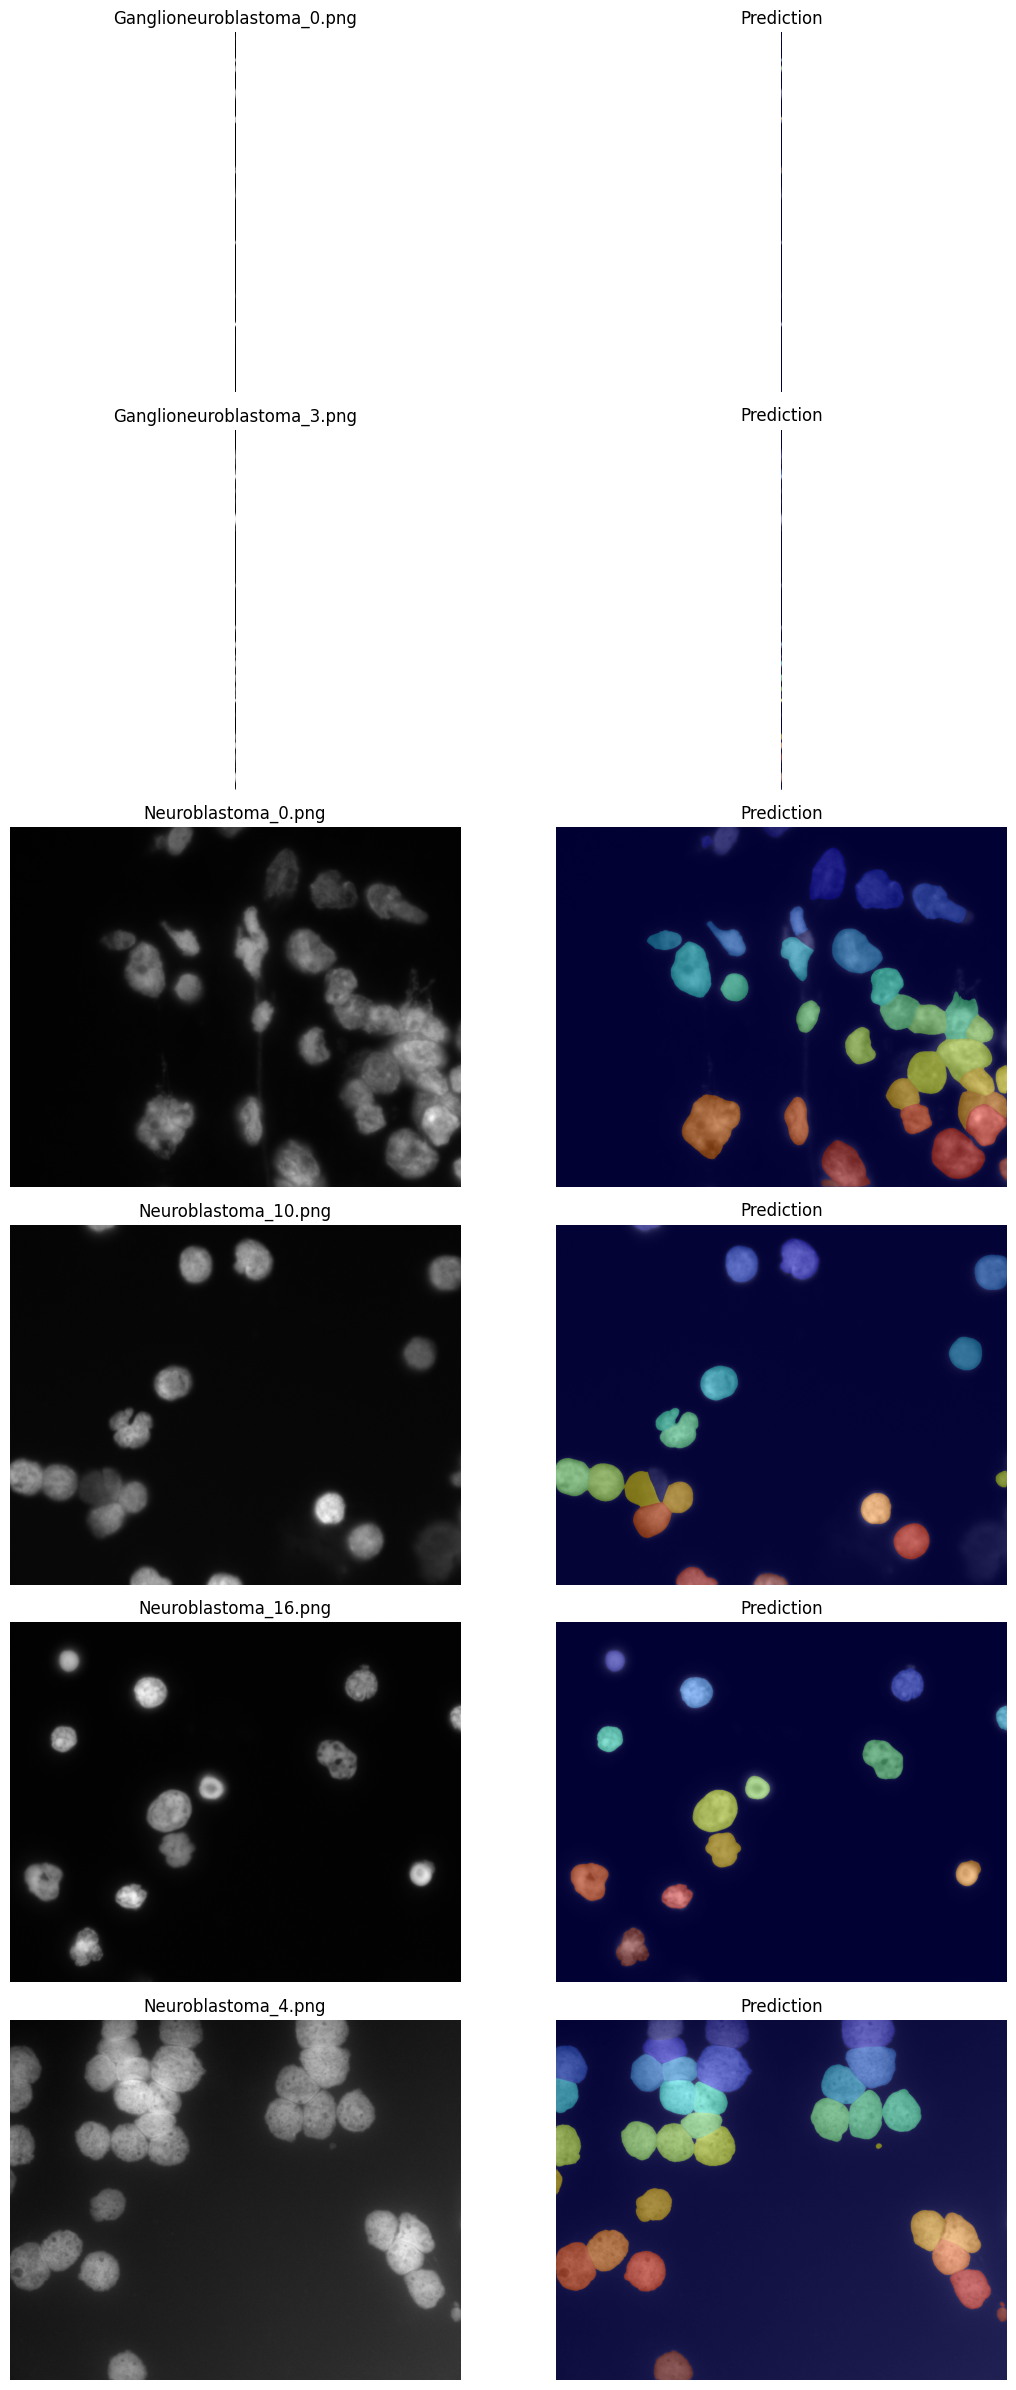

In [24]:
def predict_and_plot(model_dir, test_dir, n=6, channels=None):
    """
    Show raw image + predicted mask overlays for first n test images.
    Works with Cellpose v4 (3-return eval()) and older (4-return).
    """
    model = models.CellposeModel(gpu=True, pretrained_model=model_dir)
    pngs  = sorted([f for f in os.listdir(test_dir) if f.endswith('.png')])[:n]

    if len(pngs) == 0:
        print(f"No .png files found in {test_dir}")
        return

    plt.figure(figsize=(12, 4*len(pngs)))
    for i, fname in enumerate(pngs):
        img_path = os.path.join(test_dir, fname)
        img  = cp_io.imread(img_path)

        # call eval
        if channels is None:
            out = model.eval([img], diameter=None)  # let it infer single-channel
        else:
            out = model.eval([img], diameter=None, channels=channels)

        # handle v4 vs older
        if len(out) == 4:
            masks, flows, styles, diams = out
        else:
            masks, flows, styles = out
            diams = None

        pred = masks[0] if isinstance(masks, list) else masks

        plt.subplot(len(pngs), 2, 2*i + 1)
        plt.imshow(img, cmap='gray'); plt.title(fname); plt.axis('off')

        plt.subplot(len(pngs), 2, 2*i + 2)
        plt.imshow(img, cmap='gray')
        plt.imshow(pred, cmap='jet', alpha=0.4)
        plt.title('Prediction'); plt.axis('off')

    plt.tight_layout(); plt.show()

# Run it
predict_and_plot(FINETUNED_MODEL_DIR, CP_TEST_DIR, n=6, channels=[[0,0]])

In [26]:
import os
import numpy as np
import matplotlib.pyplot as plt
from cellpose import models, io as cp_io
from pathlib import Path

In [27]:
def force_2d(arr):
    """Make any array 2-D (H, W). If RGB, take the first channel."""
    arr = np.asarray(arr)
    if arr.ndim == 2:
        return arr
    if arr.ndim == 3:
        # H, W, C  -> take first channel
        if arr.shape[-1] in (3, 4):
            return arr[..., 0]
        # C, H, W  -> take first slice
        if arr.shape[0] in (3, 4):
            return arr[0, ...]
        # fallback: squeeze
        return np.squeeze(arr)
    return np.squeeze(arr)

def same_shape_or_warn(a, b, name):
    if a.shape != b.shape:
        print(f"⚠️  Shape mismatch for {name}: GT {a.shape} vs Pred {b.shape} — skipping.")
        return False
    return True

def binarize(x):
    return (x > 0).astype(np.uint8)

def dice_coef(y_true, y_pred):
    y_true = y_true.astype(bool)
    y_pred = y_pred.astype(bool)
    inter = (y_true & y_pred).sum()
    return 2 * inter / (y_true.sum() + y_pred.sum() + 1e-8)

def iou_score(y_true, y_pred):
    y_true = y_true.astype(bool)
    y_pred = y_pred.astype(bool)
    inter = (y_true & y_pred).sum()
    union = (y_true | y_pred).sum()
    return inter / (union + 1e-8)

def pixel_accuracy(y_true, y_pred):
    y_true = y_true.astype(bool)
    y_pred = y_pred.astype(bool)
    return (y_true == y_pred).mean()

In [28]:
def evaluate_pixel_metrics(model_dir, test_dir, channels=None, verbose=False):
    model = models.CellposeModel(gpu=True, pretrained_model=model_dir)
    pngs  = sorted([f for f in os.listdir(test_dir) if f.endswith('.png')])

    results = []
    skipped = 0
    for fname in pngs:
        base = os.path.splitext(fname)[0]
        img_path = os.path.join(test_dir, fname)
        gt_path  = os.path.join(test_dir, base + '_masks.npy')

        if not os.path.exists(gt_path):
            if verbose: print(f"⚠️  Missing GT for {fname}, skipping.")
            skipped += 1
            continue

        img = cp_io.imread(img_path)
        gt  = np.load(gt_path)

        # predict
        if channels is None:
            out = model.eval([img], diameter=None)
        else:
            out = model.eval([img], diameter=None, channels=channels)

        if len(out) == 4:
            masks, flows, styles, diams = out
        else:
            masks, flows, styles = out
            diams = None

        pred = masks[0] if isinstance(masks, list) else masks

        # force to 2-D
        gt_2d   = force_2d(gt)
        pred_2d = force_2d(pred)

        if not same_shape_or_warn(gt_2d, pred_2d, fname):
            skipped += 1
            continue

        gt_bin   = binarize(gt_2d)
        pred_bin = binarize(pred_2d)

        d = dice_coef(gt_bin, pred_bin)
        j = iou_score(gt_bin, pred_bin)
        a = pixel_accuracy(gt_bin, pred_bin)

        results.append((fname, d, j, a))

    if verbose:
        print(f"Evaluated {len(results)} images, skipped {skipped}.")

    return results

In [29]:
FINETUNED_MODEL_DIR = os.path.join(MODELS_DIR, 'full_gt_model')
metrics = evaluate_pixel_metrics(FINETUNED_MODEL_DIR, CP_TEST_DIR, channels=[[0,0]], verbose=True)

print("filename\tDice\tIoU\tAcc")
for f, d, j, a in metrics:
    print(f"{f}\t{d:.4f}\t{j:.4f}\t{a:.4f}")

mean_dice = np.mean([m[1] for m in metrics]) if metrics else 0
mean_iou  = np.mean([m[2] for m in metrics]) if metrics else 0
mean_acc  = np.mean([m[3] for m in metrics]) if metrics else 0

print("\nMean Dice:", round(mean_dice, 4))
print("Mean IoU :", round(mean_iou , 4))
print("Mean Acc :", round(mean_acc , 4))

⚠️  Shape mismatch for Ganglioneuroblastoma_0.png: GT (914, 1225) vs Pred (1225, 3) — skipping.


⚠️  Shape mismatch for Ganglioneuroblastoma_3.png: GT (914, 1225) vs Pred (1225, 3) — skipping.


Evaluated 14 images, skipped 2.
filename	Dice	IoU	Acc
Neuroblastoma_0.png	0.9230	0.8569	0.9711
Neuroblastoma_10.png	0.9388	0.8846	0.9894
Neuroblastoma_16.png	0.9644	0.9312	0.9956
Neuroblastoma_4.png	0.9726	0.9467	0.9887
normal_0.png	0.9400	0.8868	0.9526
normal_10.png	0.9851	0.9706	0.9914
normal_11.png	0.9823	0.9652	0.9884
normal_13.png	0.9574	0.9183	0.9871
normal_15.png	0.9627	0.9282	0.9898
normal_24.png	0.9480	0.9011	0.9613
normal_28.png	0.9847	0.9698	0.9905
normal_8.png	0.9565	0.9167	0.9704
normal_9.png	0.9730	0.9474	0.9778
otherspecimen_1.png	0.9068	0.8295	0.9850

Mean Dice: 0.9568
Mean IoU : 0.9181
Mean Acc : 0.9814


In [30]:
#how many images for trianing are been used ?
def count_training_images(train_dir):
    return len(list(Path(train_dir).glob('*_masks.npy')))

n_train_used = count_training_images(os.path.join(TRAINSETS_DIR, 'full_gt_train'))
print("🧮 #images used for training:", n_train_used)

🧮 #images used for training: 63


In [31]:
def evaluate_model_with_meta(model_dir, train_dir, test_dir, name):
    n_train = count_training_images(train_dir)
    metrics = evaluate_pixel_metrics(model_dir, test_dir, channels=[[0,0]])
    mean_dice = np.mean([m[1] for m in metrics]) if metrics else 0
    mean_iou  = np.mean([m[2] for m in metrics]) if metrics else 0
    mean_acc  = np.mean([m[3] for m in metrics]) if metrics else 0
    return {
        "model_name": name,
        "n_train": n_train,
        "mean_dice": mean_dice,
        "mean_iou": mean_iou,
        "mean_acc": mean_acc
    }

# Example (adapt names/paths to your runs)
summary = evaluate_model_with_meta(
    model_dir=os.path.join(MODELS_DIR, 'full_gt_model'),
    train_dir=os.path.join(TRAINSETS_DIR, 'full_gt_train'),
    test_dir=CP_TEST_DIR,
    name='full_gt_model'
)
summary

⚠️  Shape mismatch for Ganglioneuroblastoma_0.png: GT (914, 1225) vs Pred (1225, 3) — skipping.


⚠️  Shape mismatch for Ganglioneuroblastoma_3.png: GT (914, 1225) vs Pred (1225, 3) — skipping.


{'model_name': 'full_gt_model',
 'n_train': 63,
 'mean_dice': np.float64(0.9568065947879116),
 'mean_iou': np.float64(0.9180796368772788),
 'mean_acc': np.float64(0.9813656398228235)}

Our fine‑tuned Cellpose model achieved a mean Dice of 0.957 and mean IoU of 0.918 on a held‑out test set (n=16), indicating high overlap quality between predicted and ground-truth masks. Two images were excluded due to channel/shape inconsistencies which we are correcting. Next, we will benchmark against the pretrained nuclei model to quantify improvement, perform incremental training to assess data efficiency, and compute instance-level metrics for a more rigorous evaluation.

Pixel accuracy is inflated because the background dominates. Dice/IoU are more informative for segmentation. Keep reporting Dice/IoU as your primary metrics; you can keep accuracy as a secondary, but explain why it’s high.

In [32]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

from cellpose import models, io as cp_io

In [33]:
# your fine-tuned model
FINETUNED_MODEL_DIR = "/content/drive/MyDrive/S-BIAD634/dataset/trained_models/full_gt_model"

# LIVECell images (change to your actual path)
LIVE_CELL_IMG = "/content/drive/MyDrive/LIVECell/sample/img_0001.png"   # single image test
LIVE_CELL_DIR = "/content/drive/MyDrive/LIVECell/images"                # or a folder
OUT_DIR       = "/content/drive/MyDrive/LIVECell/preds_full_gt_model"   # where to save predictions
os.makedirs(OUT_DIR, exist_ok=True)

In [36]:
# Example: download one LIVECell test image (replace with any other path you like)
!wget https://raw.githubusercontent.com/sartorius-research/LIVECell/main/sample_images/HEK293T_0001.png -O HEK293T_0001.png

--2025-07-25 08:03:22--  https://raw.githubusercontent.com/sartorius-research/LIVECell/main/sample_images/HEK293T_0001.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2025-07-25 08:03:22 ERROR 404: Not Found.



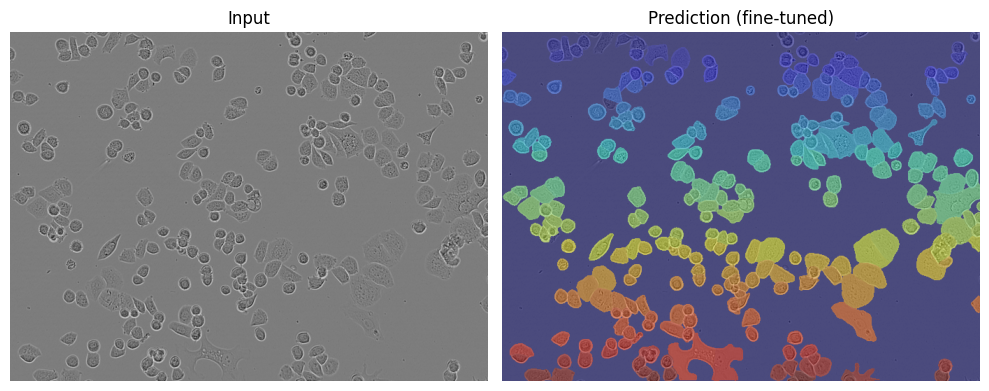

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
from cellpose import models, io as cp_io

FINETUNED_MODEL_DIR = "/content/drive/MyDrive/S-BIAD634/dataset/trained_models/full_gt_model"
TEST_IMG = "/content/SkBr3_Phase_H3_2_02d00h00m_4.tif"   # <-- put your path here

def to_gray_2d(img):
    img = np.asarray(img)
    if img.ndim == 3:     # H, W, C
        return img[..., 0]  # or img.mean(axis=-1)
    return np.squeeze(img)

def test_one_image(img_path, model_dir, diameter=None, channels=None, crop_border=0):
    model = models.CellposeModel(gpu=True, pretrained_model=model_dir)
    img = cp_io.imread(img_path)
    img = to_gray_2d(img)

    # (optional) crop dark border if you want, e.g. 10 pixels
    if crop_border > 0:
        img = img[crop_border:-crop_border, crop_border:-crop_border]

    # evaluate
    if channels is None:
        out = model.eval([img], diameter=diameter)  # v4-compatible, single channel
    else:
        out = model.eval([img], diameter=diameter, channels=channels)

    if len(out) == 4:
        masks, flows, styles, diams = out
    else:
        masks, flows, styles = out
        diams = None

    pred = masks[0] if isinstance(masks, list) else masks

    # visualise
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1); plt.imshow(img, cmap='gray'); plt.title('Input'); plt.axis('off')
    plt.subplot(1,2,2); plt.imshow(img, cmap='gray'); plt.imshow(pred, cmap='jet', alpha=0.4)
    plt.title('Prediction (fine-tuned)'); plt.axis('off')
    plt.tight_layout(); plt.show()

    return pred

_ = test_one_image(TEST_IMG, FINETUNED_MODEL_DIR, diameter=None, channels=None, crop_border=10)


Most cells are being detected (lots of differently‑colored blobs). So your Bioarchive‑fine‑tuned model does generalise somewhat to this very different modality.It can look like the whole image is segmented even when it’s not.

In [46]:
import os
print("LIVE_CELL_IMG =", LIVE_CELL_IMG)
print("Exists?        ", os.path.exists(LIVE_CELL_IMG))

LIVE_CELL_IMG = /content/drive/MyDrive/LIVECell/sample/img_0001.png
Exists?         False


In [47]:
FINETUNED_MODEL_DIR = "/content/drive/MyDrive/S-BIAD634/dataset/trained_models/full_gt_model"
LIVE_CELL_IMG = "/content/SkBr3_Phase_H3_2_02d00h00m_4.tif"   # <- your path
OUT_DIR = "/content/livecell_preds"
import os; os.makedirs(OUT_DIR, exist_ok=True)

In [48]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from skimage import io as skio
import tifffile as tiff
from cellpose import models, io as cp_io
from PIL import Image

def read_gray_2d(path):
    """Robust reader that returns a 2-D grayscale array."""
    path = str(path)
    if not os.path.exists(path):
        raise FileNotFoundError(f"Image not found: {path}")

    arr = None
    try:
        arr = cp_io.imread(path)
    except Exception:
        pass

    if arr is None:
        if Path(path).suffix.lower() in ('.tif', '.tiff'):
            arr = tiff.imread(path)
        else:
            arr = skio.imread(path)

    arr = np.asarray(arr)
    if arr.ndim == 3:             # H, W, C -> take first channel (or mean)
        arr = arr[..., 0]
    arr = np.squeeze(arr)
    if arr.ndim != 2:
        raise ValueError(f"Expected a 2-D image, got shape {arr.shape}")
    return arr

def predict_single_image_return_img(img_path, model_dir, diameter=None, channels=None):
    model = models.CellposeModel(gpu=True, pretrained_model=model_dir)
    img = read_gray_2d(img_path)

    # omit channels for grayscale to avoid the deprecation warning
    if channels is None:
        out = model.eval([img], diameter=diameter)
    else:
        out = model.eval([img], diameter=diameter, channels=channels)

    if len(out) == 4:   # old API
        masks, flows, styles, diams = out
    else:               # v4 API
        masks, flows, styles = out
        diams = None

    pred = masks[0] if isinstance(masks, list) else masks
    return pred, img

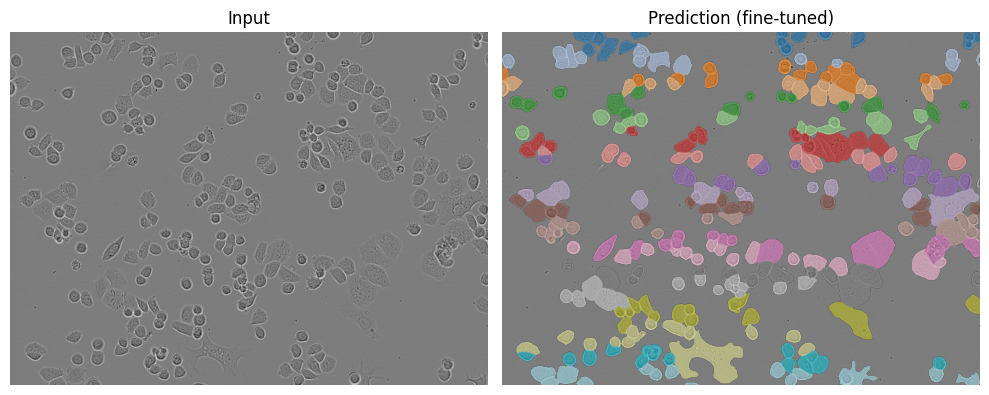

#instances:        290
Foreground pixels: 31.86%
Mean cell area:    402.2 px


In [49]:
pred, img = predict_single_image_return_img(
    LIVE_CELL_IMG, FINETUNED_MODEL_DIR, diameter=None, channels=None
)

# Transparent background overlay
m = pred.astype(float).copy()
m[m == 0] = np.nan

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(img, cmap='gray'); plt.title('Input'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(img, cmap='gray')
plt.imshow(m, cmap='tab20', alpha=0.6); plt.title('Prediction (fine-tuned)'); plt.axis('off')
plt.tight_layout(); plt.show()

# Quick sanity stats
labels = np.unique(pred)
labels = labels[labels != 0]   # drop background
n_instances = len(labels)
fg_ratio = (pred > 0).mean() * 100
mean_area = np.mean([np.sum(pred == k) for k in labels]) if n_instances > 0 else 0

print(f"#instances:        {n_instances}")
print(f"Foreground pixels: {fg_ratio:.2f}%")
print(f"Mean cell area:    {mean_area:.1f} px")

In [50]:
base = Path(LIVE_CELL_IMG).stem
np.save(os.path.join(OUT_DIR, base + "_pred_masks.npy"), pred.astype(np.uint16))
Image.fromarray(pred.astype(np.uint16)).save(os.path.join(OUT_DIR, base + "_pred_masks.tif"))
print("Saved to:", OUT_DIR)

Saved to: /content/livecell_preds


#instances: 290
Area px²: mean=402.2, median=332.0, P5=167.3, P95=829.3
Diam px : mean=21.72, median=20.56


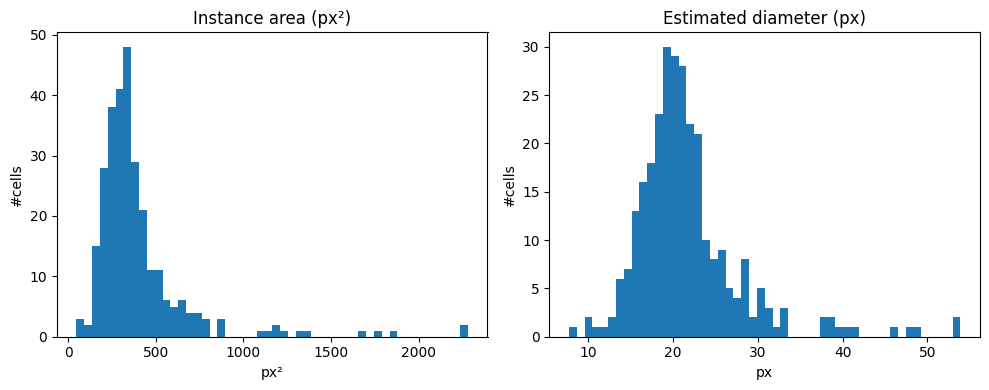

In [51]:
import numpy as np
import matplotlib.pyplot as plt

labels = np.unique(pred)[1:]  # drop background
areas = np.array([(pred == k).sum() for k in labels])
diameters = 2*np.sqrt(areas/np.pi)

print(f"#instances: {len(labels)}")
print(f"Area px²: mean={areas.mean():.1f}, median={np.median(areas):.1f}, P5={np.percentile(areas,5):.1f}, P95={np.percentile(areas,95):.1f}")
print(f"Diam px : mean={diameters.mean():.2f}, median={np.median(diameters):.2f}")

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.hist(areas, bins=50); plt.title("Instance area (px²)"); plt.xlabel("px²"); plt.ylabel("#cells")
plt.subplot(1,2,2); plt.hist(diameters, bins=50); plt.title("Estimated diameter (px)"); plt.xlabel("px"); plt.ylabel("#cells")
plt.tight_layout(); plt.show()